# MIS/MVC QAOA – Parameterized LX Initial State

This notebook demonstrates `MIS_MVC_ParameterizedInitialState`, which exposes
the LX-sweep rotation angles as variational parameters.

Three **grouping** schemes are supported:

| Scheme | `n_params` | Notes |
|---|---|---|
| `"uniform"` | 1 | One shared angle θ for all vertices – most scalable |
| `"degree"` | # distinct degrees | One angle per degree bucket – exploits graph symmetry |
| `"per_vertex"` | N | One angle per qubit – maximum expressivity |

The helper `mis_mvc_warm_start_angle` returns principled initial values based
on the mean-field argument `θ_k = arctan(1/√d_k)`, which is independent of
system size and transfers well across graph sizes via parameter concentration.

In [1]:
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qaoa import QAOA, initializers, utils
from qaoa.initialstates import MIS_MVC_ParameterizedInitialState, MIS_MVC_InitialState
from qaoa.mixers import VertexSubsetLXMixer, Grover
from qaoa.problems import MIS_MVC_Problem
from qaoa.utils.vertex_subset import mis_mvc_warm_start_angle

## Graph

We use the same small graph from https://arxiv.org/abs/2607.27915 as the
existing `ToyExample` notebook.

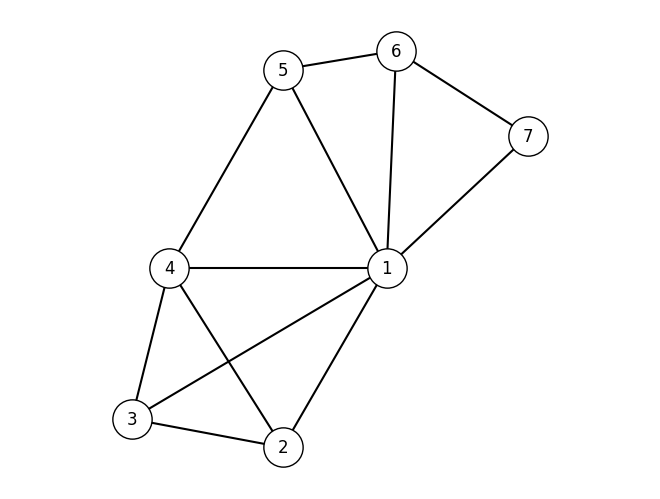

In [2]:
G = nx.Graph()

# Preserve node/qubit order: q0 -> node 1, ..., q6 -> node 7
G.add_nodes_from(range(1, 8))

G.add_edges_from([
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 5),
    (1, 6),
    (1, 7),
    (2, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
])

pos = {
    1: (0.0, 0.0),
    2: (-0.55, -0.95),
    3: (-1.35, -0.80),
    4: (-1.15, 0.0),
    5: (-0.55, 1.05),
    6: (0.05, 1.15),
    7: (0.75, 0.70),
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    edgecolors="black",
    node_size=800,
    width=1.5,
)

plt.axis("equal")
plt.show()

## Warm-start angles

`mis_mvc_warm_start_angle` computes `θ = arctan(1/√d)` for each degree
bucket, motivated by the mean-field saddle-point for feasibility-preserving
product states.  These values are graph-size independent and carry over to
larger instances.

In [3]:
theta_uniform = mis_mvc_warm_start_angle(G, grouping="uniform")
theta_degree  = mis_mvc_warm_start_angle(G, grouping="degree")
theta_vertex  = mis_mvc_warm_start_angle(G, grouping="per_vertex")

print(f"uniform   → θ = {theta_uniform:.4f}  ({np.degrees(theta_uniform):.1f}°)")
print(f"degree    → θ per bucket = {[f'{a:.4f}' for a in theta_degree]}")
print(f"per_vertex→ θ per qubit  = {[f'{a:.4f}' for a in theta_vertex]}")

uniform   → θ = 0.4952  (28.4°)
degree    → θ per bucket = ['0.6155', '0.5236', '0.4636', '0.3876']
per_vertex→ θ per qubit  = ['0.3876', '0.5236', '0.5236', '0.4636', '0.5236', '0.5236', '0.6155']


## QAOA optimization – uniform grouping

A single variational initial-state angle θ (uniform grouping) is the most
scalable choice.  We warm-start it at `θ₀ = arctan(1/√mean_degree)` via
`FixedAngles`.

The flat angle array is `[θ, gamma_0, beta_0, …]`, so the warm-start vector
needs a leading element for θ followed by dummy QAOA angles (zeros here;
the optimiser refines them from the grid).

In [5]:
problem_kind = "mis"  # change to "mvc"
initial_angle = np.pi / 3
shots=2000
maxdepth=5


init     = MIS_MVC_ParameterizedInitialState(G, problem_kind="mis", grouping="uniform")
initial_state = MIS_MVC_InitialState(
    G,
    problem_kind="mis",
    angle=initial_angle,
    phase_correct=True,
)
problem  = MIS_MVC_Problem(G, problem_kind="mis")
mixer    = VertexSubsetLXMixer(G, problem_kind="mis", multi_angle=False)
grover_mixer = Grover(initial_state)

warm_start = np.array([np.pi/3, 0.0, 0.0])


# Build a warm-start: [theta_0=arctan(1/sqrt(mean_deg)), gamma=0, beta=0]
# warm_start = np.array([theta_uniform, 0.0, 0.0])
ansaetze = {
    "LX - init grid": QAOA(
        problem=problem,
        mixer=mixer,
        initialstate=init,
        shots=shots,
        initializer=initializers.Interp(),
        # initializer=initializers.FixedAngles(warm_start),
    ),
    "Grover - init grid": QAOA(
        problem=problem,
        mixer=grover_mixer,
        initialstate=init,
        shots=shots,
        initializer=initializers.Interp(),
        # initializer=initializers.FixedAngles(warm_start),
    ),
    "LX - init warm": QAOA(
        problem=problem,
        mixer=mixer,
        initialstate=init,
        shots=shots,
        initializer=initializers.Interp(init_angles=[initial_angle]),
        # initializer=initializers.FixedAngles(warm_start),
    ),
    "Grover - init warm": QAOA(
        problem=problem,
        mixer=grover_mixer,
        initialstate=init,
        shots=shots,
        initializer=initializers.Interp(init_angles=[initial_angle]),
        # initializer=initializers.FixedAngles(warm_start),
    ),
    "LX": QAOA(
        problem=problem,
        mixer=mixer,
        initialstate=initial_state,
        shots=shots,
        initializer=initializers.Interp(),
        # initializer=initializers.FixedAngles(warm_start),
    ),
    "Grover": QAOA(
        problem=problem,
        mixer=grover_mixer,
        initialstate=initial_state,
        shots=shots,
        initializer=initializers.Interp(),
        # initializer=initializers.FixedAngles(warm_start),
    ),
}

In [6]:
for label, qaoa in ansaetze.items():
    print(f"{label} ansatz...")
    print(qaoa.createParameterizedCircuit(depth=1))
    print(qaoa.n_init)


LX - init grid ansatz...
None
1
Grover - init grid ansatz...
None
1
LX - init warm ansatz...
None
1
Grover - init warm ansatz...
None
1
LX ansatz...
None
0
Grover ansatz...
None
0


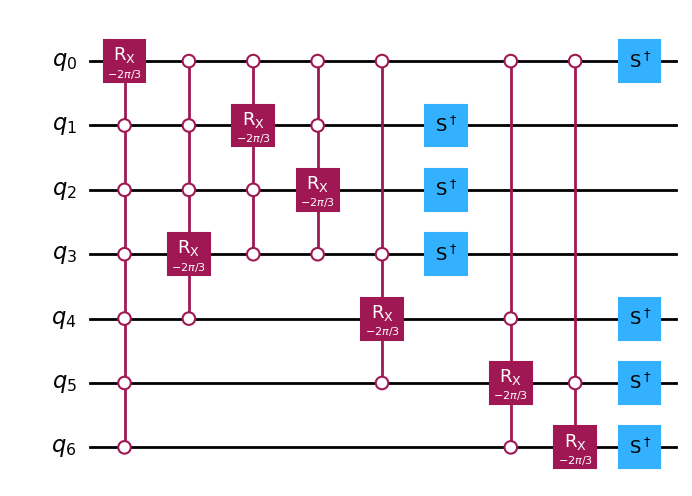

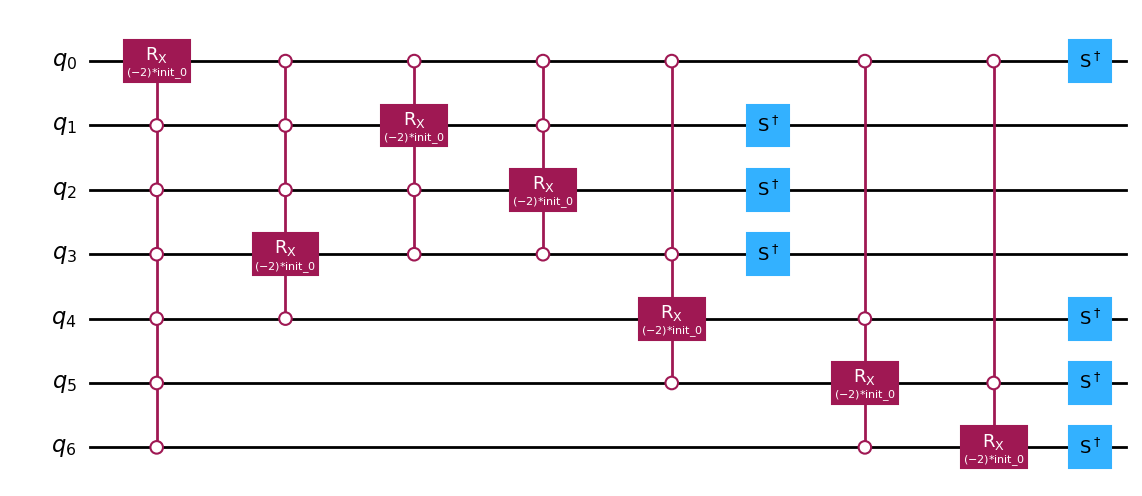

In [7]:
initial_state.create_circuit()
init.create_circuit()

display(initial_state.circuit.draw("mpl", fold=-1))
display(init.circuit.draw("mpl", fold=-1))

## Comparing groupings at depth 1

We run all three groupings and compare the best CVaR energy.

In [8]:
for label, qaoa in ansaetze.items():
    if "init grid" in label:
        qaoa.sample_cost_landscape(angles={"init": [0, np.pi, 10], "gamma": [0, 2 * np.pi, 20], "beta": [0, 2 * np.pi, 20]})
        # print("yes", label)
    else:
        qaoa.sample_cost_landscape(angles={"gamma": [0, 2 * np.pi, 20], "beta": [0, 2 * np.pi, 20]})
        # print("no", label)

2026-09-04 15:01:34 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-09-04 15:01:34 [info     ] Circuit is already of depth 1  file=qaoa.qaoa
2026-09-04 15:01:35 [info     ] Executing sample_cost_landscape — 4000 circuits (init×beta×gamma = 10×20×20) file=qaoa.qaoa func=sample_cost_landscape
2026-09-04 15:01:35 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-09-04 15:04:12 [info     ] Done measurement - best params: 2.1991 (index 7/9) file=qaoa.qaoa func=sample_cost_landscape
2026-09-04 15:04:12 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
2026-09-04 15:04:12 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-09-04 15:04:12 [info     ] Circuit is already of depth 1  file=qaoa.qaoa
2026-09-04 15:04:15 [info     ] Executing sample_cost_landscape — 4000 circuits (init×beta×gamma = 10×20×20) file=q

In [9]:
for label, qaoa in ansaetze.items():
    print(f"Optimizing {label} ansatz...")
    qaoa.optimize(depth=maxdepth)

Optimizing LX - init grid ansatz...
2026-09-04 15:07:59 [info     ] Circuit is already of depth 1  file=qaoa.qaoa
2026-09-04 15:08:00 [info     ] energy(depth 1) = -2.0515000000000003 file=qaoa.qaoa func=optimize
2026-09-04 15:08:03 [info     ] energy(depth 2) = -2.0185      file=qaoa.qaoa func=optimize
2026-09-04 15:08:07 [info     ] energy(depth 3) = -2.085       file=qaoa.qaoa func=optimize
2026-09-04 15:08:15 [info     ] energy(depth 4) = -2.123       file=qaoa.qaoa func=optimize
2026-09-04 15:08:27 [info     ] energy(depth 5) = -2.3215000000000003 file=qaoa.qaoa func=optimize
Optimizing Grover - init grid ansatz...
2026-09-04 15:08:27 [info     ] Circuit is already of depth 1  file=qaoa.qaoa
2026-09-04 15:08:28 [info     ] energy(depth 1) = -2.126       file=qaoa.qaoa func=optimize
2026-09-04 15:08:32 [info     ] energy(depth 2) = -2.2030000000000003 file=qaoa.qaoa func=optimize
2026-09-04 15:08:41 [info     ] energy(depth 3) = -2.6690000000000005 file=qaoa.qaoa func=optimize
2026

In [10]:
idx = np.unravel_index(
    np.argmin(qaoa.Energy_sampled_p1),
    qaoa.Energy_sampled_p1.shape,
)

grid_candidate = np.array(
    [qaoa.best_init_val] * qaoa.n_init
    + [qaoa.gamma_grid[idx[1]]] * qaoa.n_gamma
    + [qaoa.beta_grid[idx[0]]] * qaoa.n_beta
)

print("Grid estimate:", qaoa.Energy_sampled_p1[idx])
# print("Fresh evaluations:", [qaoa._eval_energy(grid_candidate) for _ in range(10)])
print("Optimizer result:", qaoa.get_energy(depth=1))

Grid estimate: -2.0815
Optimizer result: -2.0765


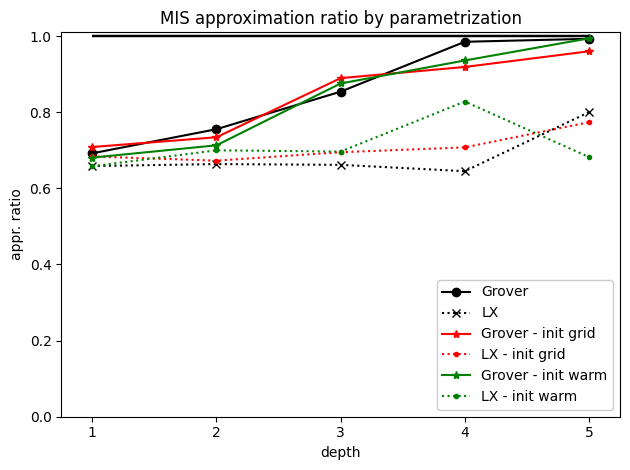

In [11]:
objmin, objmax = problem.objective_bounds()

fig = plt.figure()
utils.plot_ApproximationRatio(ansaetze["Grover"], maxdepth, objmin, objmax, label="Grover", style="k-o", fig=fig)
utils.plot_ApproximationRatio(ansaetze["LX"], maxdepth, objmin, objmax, label="LX", style="k:x", fig=fig)
utils.plot_ApproximationRatio(ansaetze["Grover - init grid"], maxdepth, objmin, objmax, label="Grover - init grid", style="r-*", fig=fig)
utils.plot_ApproximationRatio(ansaetze["LX - init grid"], maxdepth, objmin, objmax, label="LX - init grid", style="r:.", fig=fig)
utils.plot_ApproximationRatio(ansaetze["Grover - init warm"], maxdepth, objmin, objmax, label="Grover - init warm", style="g-*", fig=fig)
utils.plot_ApproximationRatio(ansaetze["LX - init warm"], maxdepth, objmin, objmax, label="LX - init warm", style="g:.", fig=fig)
plt.title(f"{problem_kind.upper()} approximation ratio by parametrization")
plt.tight_layout()

In [12]:
for label, qaoa in ansaetze.items():
    print(f"{label} ansatz...")
    depth=1
    # print(qaoa.gamma_params, qaoa.beta_params, qaoa.init_params,
    # print(          qaoa.get_angles(depth)[:qaoa.n_init])
    print(          qaoa.get_angles(depth))

ansaetze["Grover"].get_beta(depth=1), ansaetze["Grover"].get_gamma(depth=1), np.pi/3

LX - init grid ansatz...
[2.3947241  5.08833967 4.43618637]
Grover - init grid ansatz...
[0.91454782 4.42538842 2.48936198]
LX - init warm ansatz...
[2.25611258 6.7637472  4.66732828]
Grover - init warm ansatz...
[0.97864827 3.80894679 3.09342978]
LX ansatz...
[0.         4.71238898]
Grover ansatz...
[4.21896986 2.68647685]


(array([2.68647685]), array([4.21896986]), 1.0471975511965976)